In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
raw_path = '../data/raw/'

print("📁 Files in raw folder:")
for file in os.listdir(raw_path):
    if file.endswith('.csv'):
        print(f"  - {file}")

# Load datasets
df1 = pd.read_csv(raw_path + 'wearable_sleep_stress.csv')
df2 = pd.read_csv(raw_path + 'student_lifestyle_stress.csv')
df3 = pd.read_csv(raw_path + 'lifestyle_stress.csv')

print(f"\n✅ Wearable: {df1.shape}")
print(f"✅ Student: {df2.shape}")
print(f"✅ Lifestyle: {df3.shape}")


📁 Files in raw folder:
  - wearable_sleep_stress.csv
  - lifestyle_stress.csv
  - student_lifestyle_stress.csv

✅ Wearable: (10000, 16)
✅ Student: (25500, 9)
✅ Lifestyle: (1200, 7)


In [3]:
print("="*60)
print("PREPROCESSING: WEARABLE DATASET")
print("="*60)

df1_clean = df1.copy()

# Encode Daily_Stress_Level
stress_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df1_clean['Daily_Stress_Level_Encoded'] = df1_clean['Daily_Stress_Level'].map(stress_mapping)

# Encode Gender
le_gender = LabelEncoder()
df1_clean['Gender_Encoded'] = le_gender.fit_transform(df1_clean['Gender'])

# Encode Diet_Type
le_diet = LabelEncoder()
df1_clean['Diet_Type_Encoded'] = le_diet.fit_transform(df1_clean['Diet_Type'])

# Encode Physical_Activity_Level
activity_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df1_clean['Physical_Activity_Level_Encoded'] = df1_clean['Physical_Activity_Level'].map(activity_mapping)

# Drop original categorical columns
df1_clean = df1_clean.drop(['Gender', 'Diet_Type', 'Physical_Activity_Level', 'Daily_Stress_Level'], axis=1)

# Impute missing values
numeric_cols1 = df1_clean.select_dtypes(include=['int64', 'float64']).columns
imputer1 = SimpleImputer(strategy='median')
df1_clean[numeric_cols1] = imputer1.fit_transform(df1_clean[numeric_cols1])

print(f"✅ Wearable dataset ready: {df1_clean.shape}")

PREPROCESSING: WEARABLE DATASET
✅ Wearable dataset ready: (10000, 16)


In [4]:
print("="*60)
print("PREPROCESSING: STUDENT DATASET")
print("="*60)

df2_clean = df2.copy()

# Impute missing values
numeric_cols2 = df2_clean.select_dtypes(include=['int64', 'float64']).columns
imputer2 = SimpleImputer(strategy='median')
df2_clean[numeric_cols2] = imputer2.fit_transform(df2_clean[numeric_cols2])

# Encode Student_Type
df2_clean['Student_Type'] = df2_clean['Student_Type'].fillna(df2_clean['Student_Type'].mode()[0])
le_student = LabelEncoder()
df2_clean['Student_Type_Encoded'] = le_student.fit_transform(df2_clean['Student_Type'])
df2_clean = df2_clean.drop(['Student_Type'], axis=1)

print(f"✅ Student dataset ready: {df2_clean.shape}")


PREPROCESSING: STUDENT DATASET
✅ Student dataset ready: (25500, 9)


In [5]:
print("="*60)
print("PREPROCESSING: LIFESTYLE DATASET")
print("="*60)

df3_clean = df3.copy()
print(f"✅ Lifestyle dataset ready: {df3_clean.shape}")

PREPROCESSING: LIFESTYLE DATASET
✅ Lifestyle dataset ready: (1200, 7)


In [6]:
print("="*60)
print("FEATURES & TARGET")
print("="*60)

# Wearable
X1 = df1_clean.drop(['User_ID', 'Daily_Stress_Level_Encoded'], axis=1)
y1 = df1_clean['Daily_Stress_Level_Encoded']
print(f"✅ Wearable: X={X1.shape}, y={y1.shape}")

# Student
X2 = df2_clean.drop(['Stress_Level'], axis=1)
y2 = df2_clean['Stress_Level']
print(f"✅ Student: X={X2.shape}, y={y2.shape}")

# Lifestyle
X3 = df3_clean.drop(['stress_level'], axis=1)
y3 = df3_clean['stress_level']
print(f"✅ Lifestyle: X={X3.shape}, y={y3.shape}")

FEATURES & TARGET
✅ Wearable: X=(10000, 14), y=(10000,)
✅ Student: X=(25500, 8), y=(25500,)
✅ Lifestyle: X=(1200, 6), y=(1200,)


In [7]:
print("="*60)
print("SMOTE + SCALING")
print("="*60)

# Wearable
smote = SMOTE(random_state=42)
X1_resampled, y1_resampled = smote.fit_resample(X1, y1)
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1_resampled)
print(f"✅ Wearable: {X1_scaled.shape}, Target: {np.unique(y1_resampled, return_counts=True)}")

# Student
X2_resampled, y2_resampled = smote.fit_resample(X2, y2)
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2_resampled)
print(f"✅ Student: {X2_scaled.shape}, Target: {np.unique(y2_resampled, return_counts=True)}")

# Lifestyle
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)
print(f"✅ Lifestyle: {X3_scaled.shape}, Target: {np.unique(y3, return_counts=True)}")

SMOTE + SCALING
✅ Wearable: (17367, 14), Target: (array([0., 1., 2.]), array([5789, 5789, 5789]))
✅ Student: (35706, 8), Target: (array([0., 1.]), array([17853, 17853]))
✅ Lifestyle: (1200, 6), Target: (array([0, 1, 2]), array([400, 400, 400]))


In [8]:
print("="*60)
print("TRAIN-TEST SPLIT (80/20)")
print("="*60)

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1_scaled, y1_resampled, test_size=0.2, random_state=42, stratify=y1_resampled
)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y2_resampled, test_size=0.2, random_state=42, stratify=y2_resampled
)
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3_scaled, y3, test_size=0.2, random_state=42, stratify=y3
)

print(f"✅ Wearable: Train {X1_train.shape[0]}, Test {X1_test.shape[0]}")
print(f"✅ Student: Train {X2_train.shape[0]}, Test {X2_test.shape[0]}")
print(f"✅ Lifestyle: Train {X3_train.shape[0]}, Test {X3_test.shape[0]}")

TRAIN-TEST SPLIT (80/20)
✅ Wearable: Train 13893, Test 3474
✅ Student: Train 28564, Test 7142
✅ Lifestyle: Train 960, Test 240


In [9]:
print("="*60)
print("MODEL TRAINING (FIXED)")
print("="*60)

# Define models with proper parameters
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss', objective='multi:softmax', num_class=3)
}

def train_evaluate(model, X_train, X_test, y_train, y_test, name, dataset_name=""):
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted')
        rec = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        print(f"\n📊 {name} ({dataset_name})")
        print(f"   Accuracy:  {acc:.4f}")
        print(f"   Precision: {prec:.4f}")
        print(f"   Recall:    {rec:.4f}")
        print(f"   F1-Score:  {f1:.4f}")
        
        return {'model': model, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'y_pred': y_pred}
    except Exception as e:
        print(f"\n❌ {name} ({dataset_name}) failed: {e}")
        return {'model': model, 'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0, 'y_pred': None}

# Dictionary to store all results
results_wearable = {}
results_student = {}
results_lifestyle = {}

# Train on Wearable
print("\n🚀 WEARABLE DATASET")
for name, model in models.items():
    results_wearable[name] = train_evaluate(model, X1_train, X1_test, y1_train, y1_test, name, "Wearable")

# Train on Student
print("\n🚀 STUDENT DATASET")
for name, model in models.items():
    # For Student dataset, XGBoost needs binary classification (2 classes)
    if name == 'XGBoost':
        model_binary = XGBClassifier(random_state=42, eval_metric='logloss', objective='binary:logistic')
        results_student[name] = train_evaluate(model_binary, X2_train, X2_test, y2_train, y2_test, name, "Student")
    else:
        results_student[name] = train_evaluate(model, X2_train, X2_test, y2_train, y2_test, name, "Student")

# Train on Lifestyle
print("\n🚀 LIFESTYLE DATASET")
for name, model in models.items():
    results_lifestyle[name] = train_evaluate(model, X3_train, X3_test, y3_train, y3_test, name, "Lifestyle")

print("\n✅ All models trained successfully!")

MODEL TRAINING (FIXED)

🚀 WEARABLE DATASET

📊 Logistic Regression (Wearable)
   Accuracy:  0.7026
   Precision: 0.6992
   Recall:    0.7026
   F1-Score:  0.7003

📊 Random Forest (Wearable)
   Accuracy:  0.8359
   Precision: 0.8331
   Recall:    0.8359
   F1-Score:  0.8340

📊 XGBoost (Wearable)
   Accuracy:  0.8325
   Precision: 0.8295
   Recall:    0.8325
   F1-Score:  0.8301

🚀 STUDENT DATASET

📊 Logistic Regression (Student)
   Accuracy:  0.7908
   Precision: 0.7909
   Recall:    0.7908
   F1-Score:  0.7908

📊 Random Forest (Student)
   Accuracy:  0.8682
   Precision: 0.8683
   Recall:    0.8682
   F1-Score:  0.8682

📊 XGBoost (Student)
   Accuracy:  0.8589
   Precision: 0.8594
   Recall:    0.8589
   F1-Score:  0.8588

🚀 LIFESTYLE DATASET

📊 Logistic Regression (Lifestyle)
   Accuracy:  0.9792
   Precision: 0.9797
   Recall:    0.9792
   F1-Score:  0.9792

📊 Random Forest (Lifestyle)
   Accuracy:  0.9625
   Precision: 0.9631
   Recall:    0.9625
   F1-Score:  0.9626

📊 XGBoost (Life

In [10]:
print("="*60)
print("RESULT COMPARISON")
print("="*60)

comparison_data = []
for dataset_name, results in [('Wearable', results_wearable), ('Student', results_student), ('Lifestyle', results_lifestyle)]:
    for model_name, metrics in results.items():
        comparison_data.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1']
        })

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

# Best models
for dataset in ['Wearable', 'Student', 'Lifestyle']:
    best = df_comparison[df_comparison['Dataset'] == dataset].sort_values('Accuracy', ascending=False).iloc[0]
    print(f"✅ Best {dataset} model: {best['Model']} (Accuracy: {best['Accuracy']:.4f})")

RESULT COMPARISON


,Dataset,Model,Accuracy,Precision,Recall,F1-Score
0,Wearable,Logistic Regression,0.702648,0.699181,0.702648,0.700282
1,Wearable,Random Forest,0.835924,0.833083,0.835924,0.833979
2,Wearable,XGBoost,0.832470,0.829482,0.832470,0.830063
3,Student,Logistic Regression,0.790815,0.790908,0.790815,0.790798
4,Student,Random Forest,0.868244,0.868272,0.868244,0.868242
5,Student,XGBoost,0.858863,0.859400,0.858863,0.858810
6,Lifestyle,Logistic Regression,0.979167,0.979662,0.979167,0.979240
7,Lifestyle,Random Forest,0.962500,0.963137,0.962500,0.962648
8,Lifestyle,XGBoost,0.970833,0.970986,0.970833,0.970885


✅ Best Wearable model: Random Forest (Accuracy: 0.8359)
✅ Best Student model: Random Forest (Accuracy: 0.8682)
✅ Best Lifestyle model: Logistic Regression (Accuracy: 0.9792)


CONFUSION MATRIX - BEST MODELS
✅ Wearable: Random Forest
✅ Student: Random Forest
✅ Lifestyle: Logistic Regression


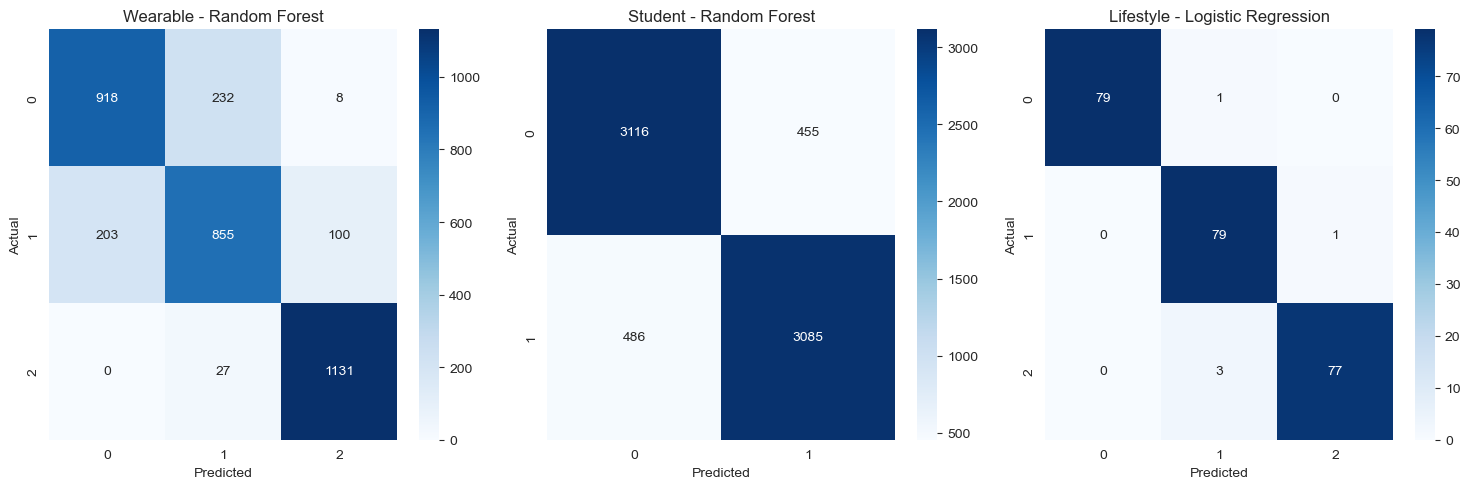

In [11]:
# Confusion Matrix for best model
print("="*60)
print("CONFUSION MATRIX - BEST MODELS")
print("="*60)

# Find best model for each dataset
best_models = {}
for dataset_name, results in [('Wearable', results_wearable), ('Student', results_student), ('Lifestyle', results_lifestyle)]:
    if results:
        best_model_name = max(results, key=lambda x: results[x]['accuracy'])
        best_models[dataset_name] = {
            'name': best_model_name,
            'y_pred': results[best_model_name]['y_pred'],
            'model': results[best_model_name]['model']
        }
        print(f"✅ {dataset_name}: {best_model_name}")

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (dataset_name, info) in enumerate(best_models.items()):
    if info['y_pred'] is not None:
        if dataset_name == 'Wearable':
            y_true = y1_test
        elif dataset_name == 'Student':
            y_true = y2_test
        else:
            y_true = y3_test
        
        cm = confusion_matrix(y_true, info['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f'{dataset_name} - {info["name"]}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

print("✅ SHAP and required libraries imported!")

✅ SHAP and required libraries imported!


In [13]:
def shap_explain(model, X_train, X_test, feature_names, dataset_name, model_type='tree'):
    """
    Generate SHAP explanations for a model.
    
    Parameters:
    - model: trained model
    - X_train: training data
    - X_test: test data
    - feature_names: list of feature names
    - dataset_name: name of the dataset
    - model_type: 'tree' for Random Forest/XGBoost, 'linear' for Logistic Regression
    """
    
    # Choose explainer based on model type
    if model_type == 'tree':
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)
    elif model_type == 'linear':
        explainer = shap.LinearExplainer(model, X_train)
        shap_values = explainer.shap_values(X_test)
    else:
        raise ValueError("model_type must be 'tree' or 'linear'")
    
    # SHAP Summary Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
    plt.title(f'SHAP Summary Plot - {dataset_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'../reports/figures/shap_summary_{dataset_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # SHAP Bar Plot (Feature Importance)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar", show=False)
    plt.title(f'SHAP Feature Importance - {dataset_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'../reports/figures/shap_importance_{dataset_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return shap_values, explainer

In [14]:
# Collect best models with their types
best_models = {
    'Wearable': {
        'model': results_wearable['Random Forest']['model'],
        'X_train': X1_train,
        'X_test': X1_test,
        'feature_names': X1.columns.tolist(),
        'model_type': 'tree'  # Random Forest
    },
    'Student': {
        'model': results_student['Random Forest']['model'],
        'X_train': X2_train,
        'X_test': X2_test,
        'feature_names': X2.columns.tolist(),
        'model_type': 'tree'  # Random Forest
    },
    'Lifestyle': {
        'model': results_lifestyle['Logistic Regression']['model'],
        'X_train': X3_train,
        'X_test': X3_test,
        'feature_names': X3.columns.tolist(),
        'model_type': 'linear'  # Logistic Regression
    }
}

print("✅ Best models collected:")
for name, data in best_models.items():
    print(f"  - {name}: {data['model_type']} model")

✅ Best models collected:
  - Wearable: tree model
  - Student: tree model
  - Lifestyle: linear model



🧠 SHAP ANALYSIS: Wearable DATASET


<Figure size 1000x600 with 0 Axes>

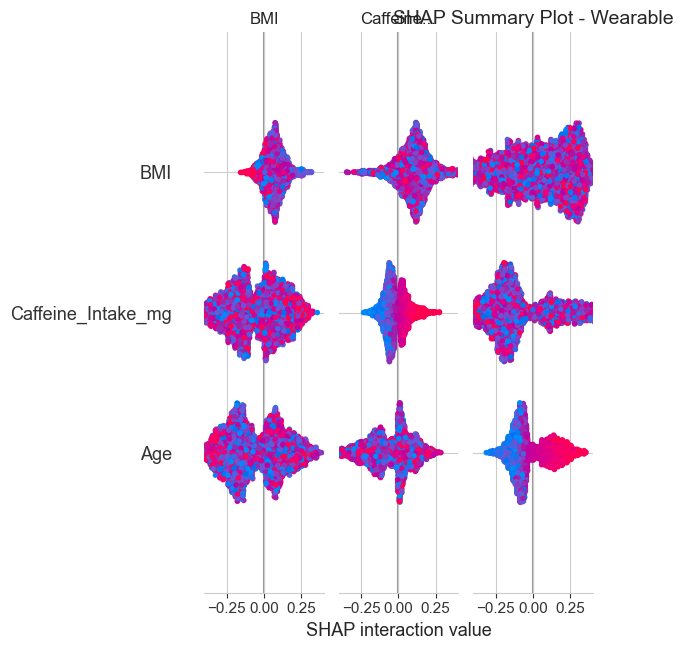

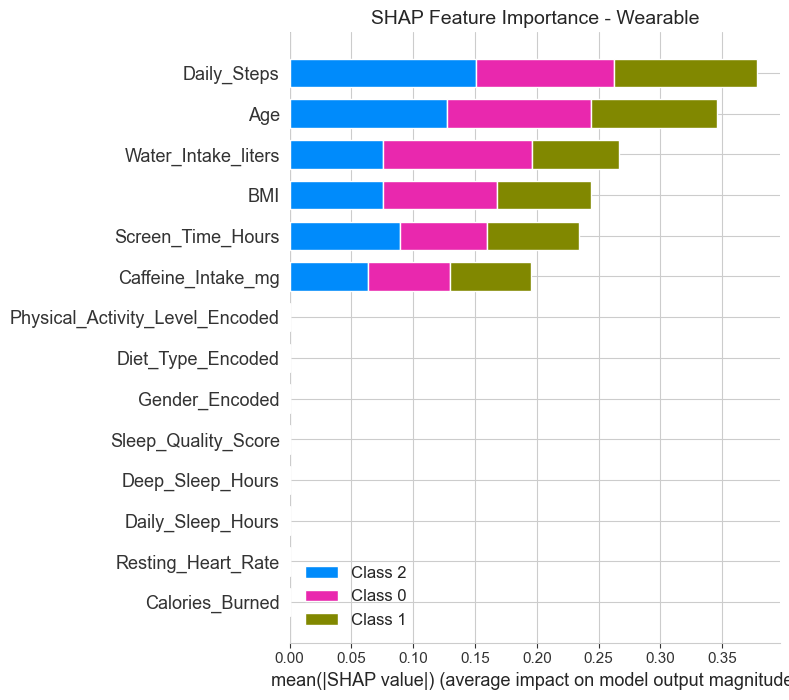


🧠 SHAP ANALYSIS: Student DATASET


<Figure size 1000x600 with 0 Axes>

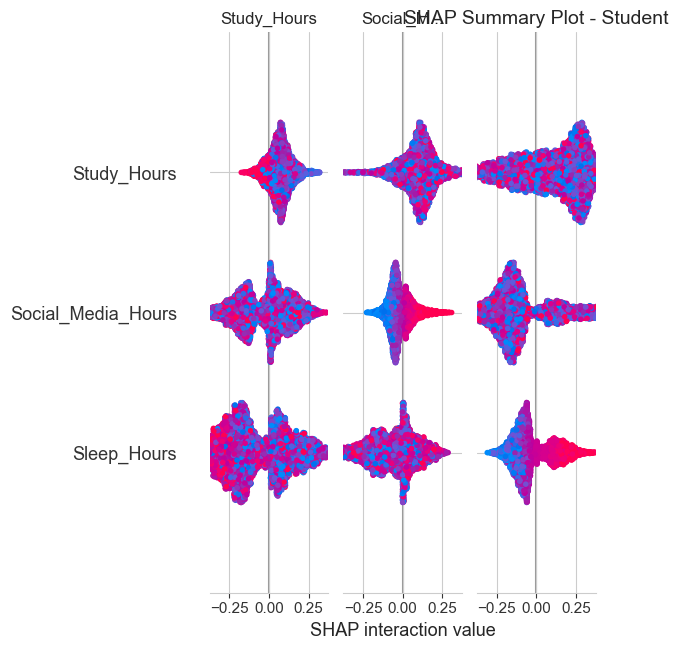

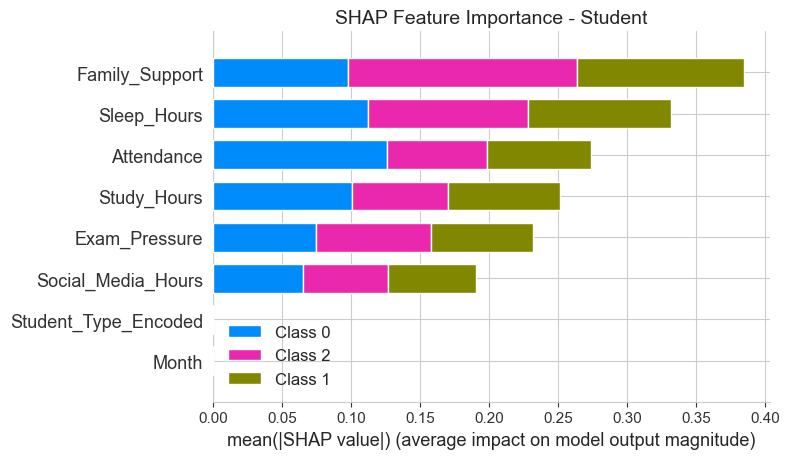


🧠 SHAP ANALYSIS: Lifestyle DATASET


<Figure size 1000x600 with 0 Axes>

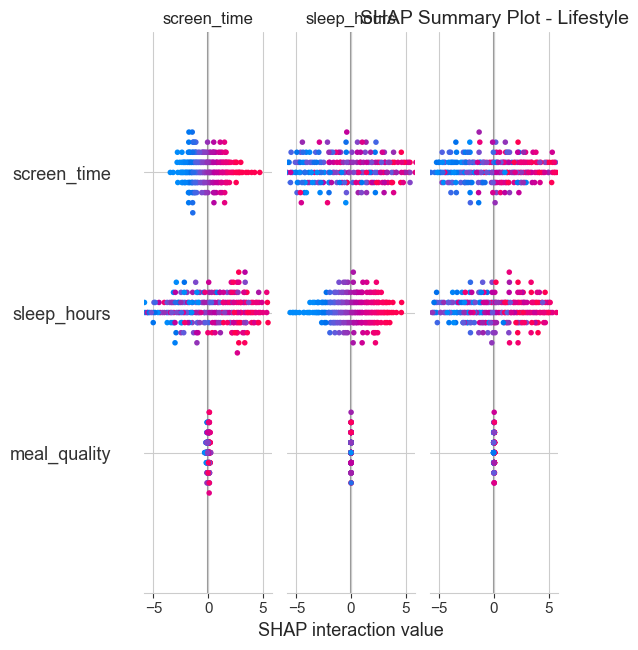

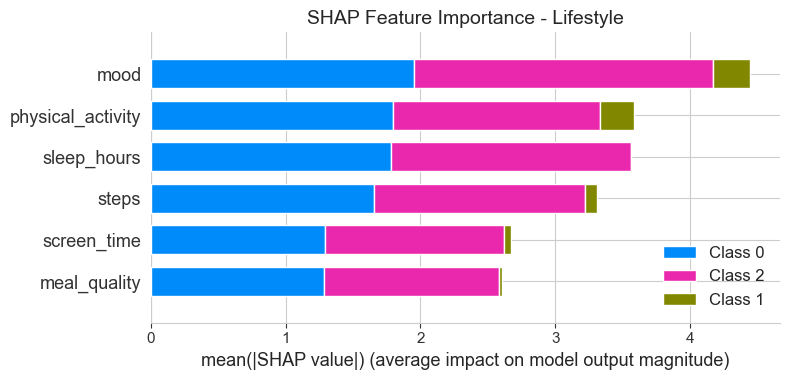


✅ SHAP analysis completed for all datasets!


In [15]:
# Run SHAP for each dataset
shap_results = {}
for name, data in best_models.items():
    print(f"\n{'='*60}")
    print(f"🧠 SHAP ANALYSIS: {name} DATASET")
    print(f"{'='*60}")
    
    shap_values, explainer = shap_explain(
        model=data['model'],
        X_train=data['X_train'],
        X_test=data['X_test'],
        feature_names=data['feature_names'],
        dataset_name=name,
        model_type=data['model_type']
    )
    
    shap_results[name] = {
        'shap_values': shap_values,
        'explainer': explainer
    }

print("\n✅ SHAP analysis completed for all datasets!")

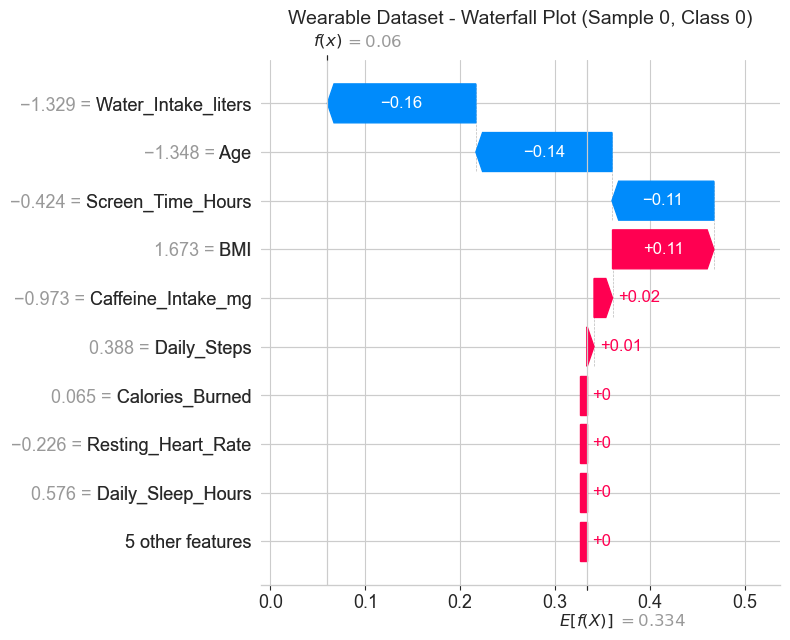

In [16]:
# Waterfall plot for the first sample from Wearable dataset
sample_idx = 0
class_idx = 0  # 0 = Low stress, 1 = Medium, 2 = High

# Extract SHAP values for the specific class
shap_values_sample = shap_results['Wearable']['shap_values'][sample_idx, :, class_idx]
X_test_sample = best_models['Wearable']['X_test'][sample_idx].reshape(1, -1)
feature_names = best_models['Wearable']['feature_names']

# Get base value for the specific class
base_value = shap_results['Wearable']['explainer'].expected_value
if isinstance(base_value, list) or isinstance(base_value, np.ndarray):
    base_value = base_value[class_idx]

plt.figure(figsize=(12, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_sample,
        base_values=base_value,
        data=X_test_sample.flatten(),
        feature_names=feature_names
    ),
    show=False
)
plt.title(f'Wearable Dataset - Waterfall Plot (Sample {sample_idx}, Class {class_idx})', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_wearable.png', dpi=150, bbox_inches='tight')
plt.show()

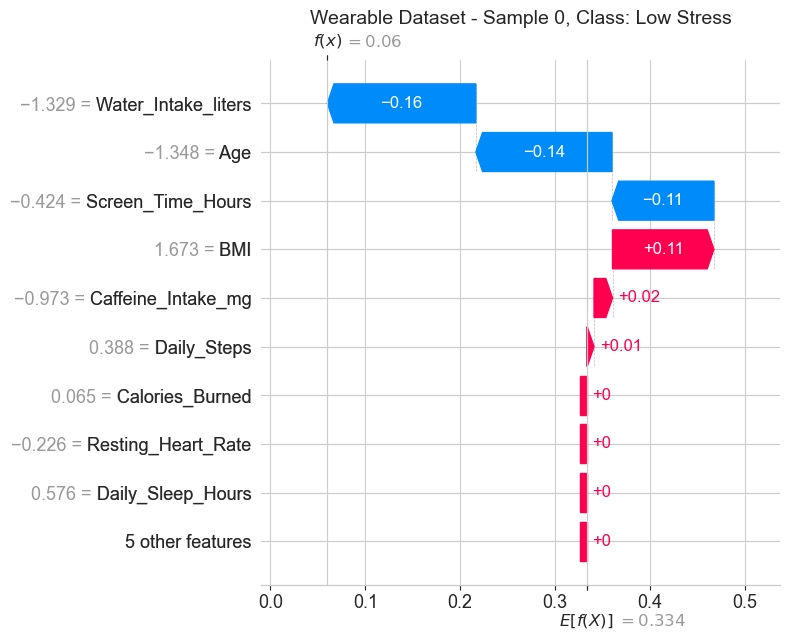

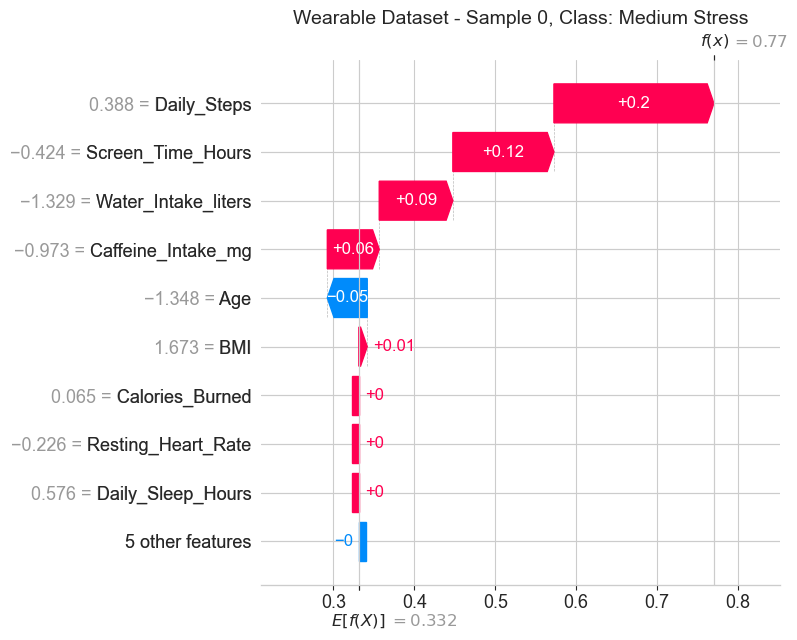

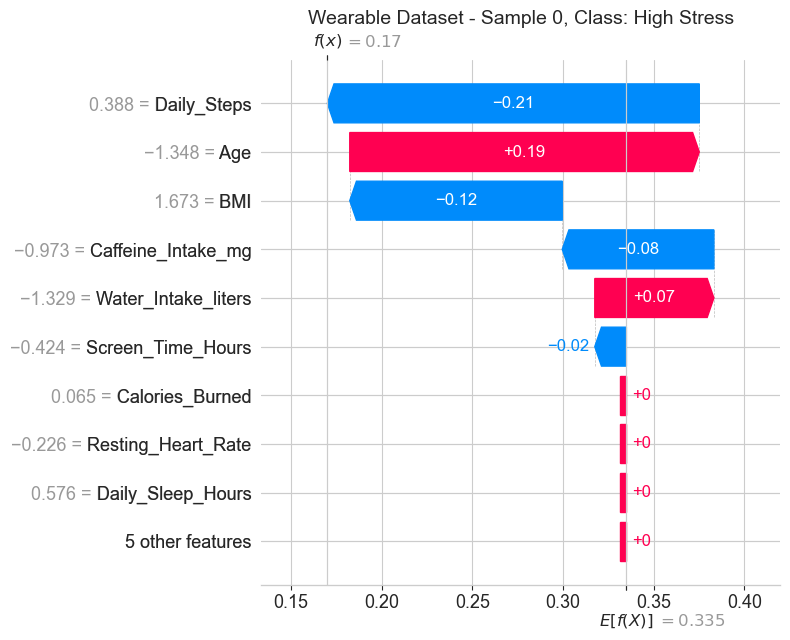

In [17]:
# Waterfall plots for all 3 classes (separate figures)
sample_idx = 0
class_names = ['Low Stress', 'Medium Stress', 'High Stress']
X_test_sample = best_models['Wearable']['X_test'][sample_idx].reshape(1, -1)
feature_names = best_models['Wearable']['feature_names']

for class_idx in range(3):
    shap_values_sample = shap_results['Wearable']['shap_values'][sample_idx, :, class_idx]
    base_value = shap_results['Wearable']['explainer'].expected_value[class_idx]
    
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_sample,
            base_values=base_value,
            data=X_test_sample.flatten(),
            feature_names=feature_names
        ),
        show=False
    )
    plt.title(f'Wearable Dataset - Sample {sample_idx}, Class: {class_names[class_idx]}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'../reports/figures/shap_waterfall_wearable_class_{class_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [18]:
# Check if all figures are saved
import os

figures_path = '../reports/figures/'
print("📁 All SHAP Figures:")
for file in sorted(os.listdir(figures_path)):
    if 'shap' in file and file.endswith('.png'):
        print(f"  - {file}")

📁 All SHAP Figures:
  - shap_importance_Lifestyle.png
  - shap_importance_Student.png
  - shap_importance_Wearable.png
  - shap_summary_Lifestyle.png
  - shap_summary_Student.png
  - shap_summary_Wearable.png
  - shap_waterfall_wearable.png
  - shap_waterfall_wearable_class_0.png
  - shap_waterfall_wearable_class_1.png
  - shap_waterfall_wearable_class_2.png


In [19]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# ========================================
# Save Best Models
# ========================================
# Wearable
joblib.dump(results_wearable['Random Forest']['model'], 'models/best_wearable_model.pkl')
print("✅ Saved: models/best_wearable_model.pkl")

# Student
joblib.dump(results_student['Random Forest']['model'], 'models/best_student_model.pkl')
print("✅ Saved: models/best_student_model.pkl")

# Lifestyle
joblib.dump(results_lifestyle['Logistic Regression']['model'], 'models/best_lifestyle_model.pkl')
print("✅ Saved: models/best_lifestyle_model.pkl")

# ========================================
# Save Scalers
# ========================================
joblib.dump(scaler1, 'models/scaler_wearable.pkl')
print("✅ Saved: models/scaler_wearable.pkl (already exists)")

joblib.dump(scaler2, 'models/scaler_student.pkl')
print("✅ Saved: models/scaler_student.pkl")

joblib.dump(scaler3, 'models/scaler_lifestyle.pkl')
print("✅ Saved: models/scaler_lifestyle.pkl")

# ========================================
# Save SHAP Explainers
# ========================================
joblib.dump(shap_results['Wearable']['explainer'], 'models/shap_explainer_Wearable.pkl')
print("✅ Saved: models/shap_explainer_Wearable.pkl")

joblib.dump(shap_results['Student']['explainer'], 'models/shap_explainer_Student.pkl')
print("✅ Saved: models/shap_explainer_Student.pkl")

joblib.dump(shap_results['Lifestyle']['explainer'], 'models/shap_explainer_Lifestyle.pkl')
print("✅ Saved: models/shap_explainer_Lifestyle.pkl")

# ========================================
# Verify all files are saved
# ========================================
print("\n📁 All files in models/ folder:")
for file in sorted(os.listdir('models/')):
    print(f"  - {file}")

✅ Saved: models/best_wearable_model.pkl
✅ Saved: models/best_student_model.pkl
✅ Saved: models/best_lifestyle_model.pkl
✅ Saved: models/scaler_wearable.pkl (already exists)
✅ Saved: models/scaler_student.pkl
✅ Saved: models/scaler_lifestyle.pkl
✅ Saved: models/shap_explainer_Wearable.pkl
✅ Saved: models/shap_explainer_Student.pkl
✅ Saved: models/shap_explainer_Lifestyle.pkl

📁 All files in models/ folder:
  - best_lifestyle_model.pkl
  - best_student_model.pkl
  - best_wearable_model.pkl
  - scaler_lifestyle.pkl
  - scaler_student.pkl
  - scaler_wearable.pkl
  - shap_explainer_Lifestyle.pkl
  - shap_explainer_Student.pkl
  - shap_explainer_Wearable.pkl


In [20]:
import joblib

# Load the model
model = joblib.load('/Users/home/Desktop/FitSense-XAI/models/best_wearable_model.pkl')

# Check number of features
print(f"Number of features expected: {model.n_features_in_}")

# Check feature names (if available
if hasattr(model, 'feature_names_in_'):
    print(f"Feature names: {model.feature_names_in_}")
else:
    print("No feature names stored in model.")

Number of features expected: 6
No feature names stored in model.


In [21]:
# Train Random Forest with ALL 14 features
X1_full = df1_clean.drop(['User_ID', 'Daily_Stress_Level_Encoded'], axis=1)
y1 = df1_clean['Daily_Stress_Level_Encoded']

# Scale
scaler_full = StandardScaler()
X1_scaled_full = scaler_full.fit_transform(X1_full)

# Train
model_full = RandomForestClassifier(random_state=42, n_estimators=100)
model_full.fit(X1_scaled_full, y1)

# Save
joblib.dump(model_full, 'models/best_wearable_model_full.pkl')
joblib.dump(scaler_full, 'models/scaler_wearable_full.pkl')

print("✅ Full model saved with 14 features!")

✅ Full model saved with 14 features!


In [22]:
import joblib
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

print("="*60)
print("TRAINING WEARABLE MODEL WITH 14 FEATURES")
print("="*60)

# ========================================
# 1. Prepare data with ALL 14 features
# ========================================
X1_full = df1_clean.drop(['User_ID', 'Daily_Stress_Level_Encoded'], axis=1)
y1 = df1_clean['Daily_Stress_Level_Encoded']

print(f"✅ Features: {X1_full.shape[1]} columns")
print(f"   Feature names: {X1_full.columns.tolist()}")

# ========================================
# 2. Scale features
# ========================================
scaler_full = StandardScaler()
X1_scaled_full = scaler_full.fit_transform(X1_full)

print("✅ Features scaled!")

# ========================================
# 3. Train Random Forest with 14 features
# ========================================
model_full = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=10,
    min_samples_split=5
)
model_full.fit(X1_scaled_full, y1)

print("✅ Random Forest trained with 14 features!")

# ========================================
# 4. Save the new model and scaler
# ========================================
models_path = '/Users/home/Desktop/FitSense-XAI/models/'

joblib.dump(model_full, models_path + 'best_wearable_model_14features.pkl')
print("✅ Saved: models/best_wearable_model_14features.pkl")

joblib.dump(scaler_full, models_path + 'scaler_wearable_14features.pkl')
print("✅ Saved: models/scaler_wearable_14features.pkl")

# ========================================
# 5. Verify
# ========================================
print("\n📁 Verification:")
print(f"   Model expects: {model_full.n_features_in_} features")
print(f"   Feature names: {model_full.feature_names_in_.tolist()}")

TRAINING WEARABLE MODEL WITH 14 FEATURES
✅ Features: 14 columns
   Feature names: ['Age', 'BMI', 'Caffeine_Intake_mg', 'Water_Intake_liters', 'Screen_Time_Hours', 'Daily_Steps', 'Calories_Burned', 'Resting_Heart_Rate', 'Daily_Sleep_Hours', 'Deep_Sleep_Hours', 'Sleep_Quality_Score', 'Gender_Encoded', 'Diet_Type_Encoded', 'Physical_Activity_Level_Encoded']
✅ Features scaled!
✅ Random Forest trained with 14 features!
✅ Saved: models/best_wearable_model_14features.pkl
✅ Saved: models/scaler_wearable_14features.pkl

📁 Verification:
   Model expects: 14 features


AttributeError: 'RandomForestClassifier' object has no attribute 'feature_names_in_'